In [1]:
import pandas as pd
import numpy as np
import colorsys
import matplotlib.pyplot as plt

def get_hsv_metrics(row):
    sats = []
    lums = []
    for i in range(1, 6):
        r, g, b = row[f'C{i}_R'], row[f'C{i}_G'], row[f'C{i}_B']
        if pd.notnull(r):
            # Převod na 0-1 pro colorsys
            r_n, g_n, b_n = r/255.0, g/255.0, b/255.0
            # Hue, Saturation, Value
            h, s, v = colorsys.rgb_to_hsv(r_n, g_n, b_n)
            # Luminance
            lum = 0.299*r + 0.587*g + 0.114*b
            sats.append(s)
            lums.append(lum)
        
    return pd.Series([np.mean(sats), np.mean(lums)])

def analyze_genres_colors(df):
    # Separate genres into individual rows
    df_genres = df.copy()
    df_genres['Genres'] = df_genres['Genres'].fillna('').str.split('|')
    df_exploded = df_genres.explode('Genres')
    df_exploded = df_exploded[df_exploded['Genres'] != ""]

    # calculate metrics
    metrics = df_exploded.apply(get_hsv_metrics, axis=1)
    df_exploded[['Avg_Saturation', 'Avg_Luminance']] = metrics

    return df_exploded

# Load data
df = pd.read_csv('C:\\Users\\nina\\Documents\\UNI\\SEM\\thesis\\coding\\game_color_analysis\\data\\game_data.csv')
analyzed_df = analyze_genres_colors(df)

summary = analyzed_df.groupby(['Decade', 'Genres'])[['Avg_Saturation', 'Avg_Luminance']].mean().reset_index()
# print(summary)


    Decade                      Genres  Avg_Saturation  Avg_Luminance
0     1980                   Adventure        0.336781      97.105749
1     1980                      Arcade        0.413126      89.721795
2     1980           Card & Board Game        0.415982     102.815455
3     1980                    Fighting        0.393613     104.488992
4     1980  Hack and slash/Beat 'em up        0.472295      92.985161
..     ...                         ...             ...            ...
61    2000                       Sport        0.301603     112.972171
62    2000                    Strategy        0.329542     106.476318
63    2000                    Tactical        0.263366     103.503415
64    2000   Turn-based strategy (TBS)        0.328624     113.426137
65    2000                Visual Novel        0.257342     124.659832

[66 rows x 4 columns]


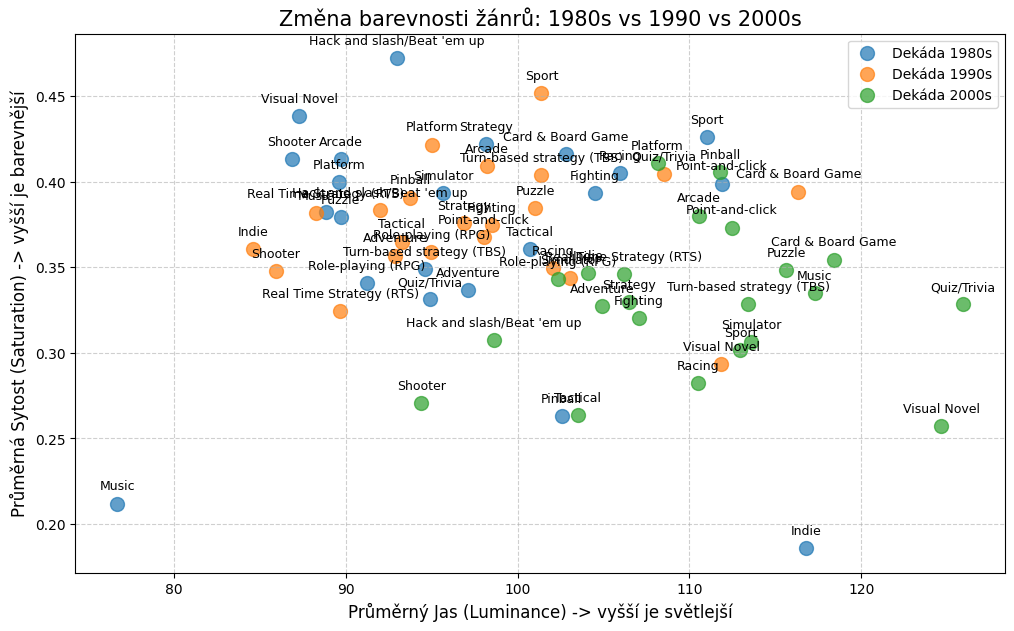

In [3]:
plt.figure(figsize=(12, 7))

for decade in [1980, 1990, 2000]:
    data = summary[summary['Decade'] == decade]
    plt.scatter(data['Avg_Luminance'], data['Avg_Saturation'], 
                label=f'Dekáda {decade}s', s=100, alpha=0.7)
    
    for i, row in data.iterrows():
        plt.annotate(row['Genres'], (row['Avg_Luminance'], row['Avg_Saturation']), 
                     textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.title('Změna barevnosti žánrů: 1980s vs 1990 vs 2000s', fontsize=15)
plt.xlabel('Průměrný Jas (Luminance) -> vyšší je světlejší', fontsize=12)
plt.ylabel('Průměrná Sytost (Saturation) -> vyšší je barevnější', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
